# Figure S6c — Axoaxonic synapse distance to the nearest axon tip

As Figure S6b, but for **axoaxonic** synapses (synapses made *onto* the sensory axon).

Restricted to the five subtypes that receive appreciable presynaptic inhibition, and to
the **2 axons per subtype whose axoaxonic synapses were manually validated** — automated
axoaxonic prediction onto sensory axons has a high false-positive rate (Figure S1a–c).

Same aggregation as panel b: one CDF per neuron, averaged within subtype, with the grey
cable-length reference curve.

**Input.** `../data/meshwork_h5/*.h5`. **Runs offline — no CAVE access.**


In [1]:
import matplotlib as mpl

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Helvetica", "Arial", "DejaVu Sans"]
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.size"] = 6

CM = 1 / 2.54


In [2]:
# Internal tag -> published label, and the Figure 3 / S6 colour scheme.
SUBTYPE_LABELS = {
    "ab-ltmr":  "Aβ-LTMR",
    "adltmr":   "Aδ-LTMR",
    "cltmr":    "C-LTMR",
    "mrgd":     "C-HTMR/Heat (MrgprD,MrgprA3,MrgprB4)",
    "sst":      "C-HTMR/Heat (SST)",
    "ad-htmr":  "Aδ-HTMR",
    "c-htmr-p": "Peptidergic C-nociceptor",
    "C-COLD":   "C-Cold",
}

PALETTE = {
    "Aβ-LTMR":                              "#556B2F",
    "Aδ-LTMR":                              "#00A86B",
    "C-LTMR":                               "#BCEBCB",
    "C-HTMR/Heat (MrgprD,MrgprA3,MrgprB4)": "#b23aee",
    "C-HTMR/Heat (SST)":                    "#ffbbff",
    "Aδ-HTMR":                              "#ff4040",
    "Peptidergic C-nociceptor":             "#ffee00",
    "C-Cold":                               "#00bfff",
}

SUBTYPE_ORDER = ["ab-ltmr", "adltmr", "cltmr", "mrgd", "sst",
                 "ad-htmr", "c-htmr-p", "C-COLD"]


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
from meshparty import meshwork

H5_DIR = Path("../data/meshwork_h5")
SUBTYPE_CSV = Path("../data/meshwork_h5_subtypes.csv")
NM_TO_UM = 1e-3


def load(coord, subdir=""):
    """Load one meshwork .h5 by its 'x_y_z' coordinate string."""
    return meshwork.load_meshwork(H5_DIR / subdir / f"{coord}.h5")


def syn_indices(neuron):
    """Mesh indices of axodendritic and axoaxonic synapses.

    The sensory neuron is the reference cell in these meshwork files, so
    `pre_syn` = synapses it makes onto dendrites (axodendritic) and
    `post_syn` = synapses made onto it (axoaxonic).
    """
    pre = getattr(neuron.anno, "pre_syn", None)
    post = getattr(neuron.anno, "post_syn", None)
    return (np.asarray([] if pre is None else pre.mesh_index, dtype=int),
            np.asarray([] if post is None else post.mesh_index, dtype=int))


def distance_to_tips_um(neuron, idx):
    """Path distance (µm) from each synapse to its nearest axon tip."""
    tips = neuron.end_points
    if len(idx) == 0 or len(tips) == 0:
        return np.array([])
    return np.min(neuron.distance_between(idx, tips), axis=1) * NM_TO_UM


/Users/wangchu/opt/anaconda3/lib/python3.8/site-packages/python_jsonschema_objects/__init__.py:113: UserWarning: Schema id not specified. Defaulting to 'self'
  warnings.warn("Schema id not specified. Defaulting to 'self'")


In [4]:
N_POINTS = 1000


def per_neuron_cdf(values_um, x_vals):
    """Empirical CDF of one neuron's synapses, interpolated onto a shared grid."""
    v = np.asarray(values_um, float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return None
    v = np.clip(v, None, x_vals[-1])
    xs = np.sort(v)
    ys = np.arange(1, xs.size + 1) / xs.size
    return np.interp(x_vals, np.r_[0.0, xs], np.r_[0.0, ys], left=0.0, right=1.0)


def cable_edges_to_tips(neuron):
    """Per skeleton edge: (distance of its midpoint to the nearest tip, its length).

    This is the grey reference curve. Each edge is weighted by the physical cable
    length it represents, so the curve answers "what fraction of the arbor lies
    within X µm of a tip?" -- the null expectation if synapses were spread evenly.
    """
    sk = neuron.skeleton
    verts = np.asarray(sk.vertices, float)
    edges = np.asarray(sk.edges, int)
    if len(edges) == 0:
        return np.array([]), np.array([])

    mesh_idx = np.asarray(sk.mesh_index)
    v_to_tip = np.min(neuron.distance_between(mesh_idx, neuron.end_points), axis=1)

    length = np.linalg.norm(verts[edges[:, 1]] - verts[edges[:, 0]], axis=1)
    midpoint = np.minimum(v_to_tip[edges[:, 0]], v_to_tip[edges[:, 1]]) + 0.5 * length
    return midpoint, length


def per_neuron_cable_cdf(dist_nm, length_nm, x_vals):
    """Cable-length-weighted CDF for one neuron."""
    d = np.asarray(dist_nm, float)
    w = np.asarray(length_nm, float)
    ok = np.isfinite(d) & np.isfinite(w) & (w > 0)
    if not ok.any():
        return None
    d, w = np.clip(d[ok] * NM_TO_UM, None, x_vals[-1]), w[ok] * NM_TO_UM
    o = np.argsort(d)
    cum = np.cumsum(w[o])
    return np.interp(x_vals, np.r_[0.0, d[o]], np.r_[0.0, cum / cum[-1]],
                     left=0.0, right=1.0)


In [5]:
# The 16 axons (2 per subtype) whose axoaxonic synapses were manually validated.
# Keys are the 'x_y_z' coordinates that name the .h5 files.
VALIDATED_COORDS = {
    "cltmr":    ["8833_3005_124", "4269_2367_2029"],
    "mrgd":     ["20373_3883_152", "24101_2062_2511"],
    "adltmr":   ["30150_8985_113", "31400_8361_125"],
    "ab-ltmr":  ["32620_7875_114", "20015_10209_299"],
    "sst":      ["5177_3371_3247", "4368_5433_963"],
    "ad-htmr":  ["27406_7510_125", "12791_2154_609"],
    "c-htmr-p": ["4146_2804_1486", "6795_4315_137"],
    "C-COLD":   ["16255_2088_2735", "5500_2063_1184"],
}


In [6]:
CAP_UM = 175.0
x_vals = np.linspace(0, CAP_UM, N_POINTS)

# Only subtypes with appreciable axoaxonic input are shown.
PANEL_C_SUBTYPES = ["ab-ltmr", "adltmr", "cltmr", "mrgd", "ad-htmr"]

syn_cdfs = {t: [] for t in PANEL_C_SUBTYPES}
cable_cdfs = []

for tag in PANEL_C_SUBTYPES:
    for coord in VALIDATED_COORDS[tag]:
        neuron = load(coord)
        _, post_idx = syn_indices(neuron)

        c = per_neuron_cdf(distance_to_tips_um(neuron, post_idx), x_vals)
        if c is not None:
            syn_cdfs[tag].append(c)
        else:
            print(f"  {tag} {coord}: no axoaxonic synapses")

        d_nm, len_nm = cable_edges_to_tips(neuron)
        cc = per_neuron_cable_cdf(d_nm, len_nm, x_vals)
        if cc is not None:
            cable_cdfs.append(cc)

for tag in PANEL_C_SUBTYPES:
    print(f"{SUBTYPE_LABELS[tag]:40s} {len(syn_cdfs[tag])} axons")


Aβ-LTMR                                  2 axons
Aδ-LTMR                                  2 axons
C-LTMR                                   2 axons
C-HTMR/Heat (MrgprD,MrgprA3,MrgprB4)     2 axons
Aδ-HTMR                                  2 axons


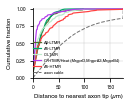

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5.0 * CM, 4.0 * CM))

for tag in PANEL_C_SUBTYPES:
    if not syn_cdfs[tag]:
        continue
    label = SUBTYPE_LABELS[tag]
    ax.plot(x_vals, np.vstack(syn_cdfs[tag]).mean(axis=0),
            color=PALETTE[label], lw=1.2, label=label)

ax.plot(x_vals, np.vstack(cable_cdfs).mean(axis=0),
        color="0.45", lw=1.0, ls="--", label="axon cable")

ax.set_xlim(0, CAP_UM)
ax.set_ylim(0, 1.01)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xlabel("Distance to nearest axon tip (µm)", fontsize=6)
ax.set_ylabel("Cumulative fraction", fontsize=6)
ax.tick_params(labelsize=5)
ax.grid(True, lw=0.3)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.legend(fontsize=4, frameon=False, loc="lower right")
fig.tight_layout()
fig.savefig("figureS6c_axoaxonic_distance_to_axon_tip.svg", format="svg", dpi=300)
plt.show()
